In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
specimen_diameter_tensile_mm = 13.94

gauge_length_mm = 50

# Elastic region
# Columns:
# [force_kN, extension_x10^-3_mm]

elastic_data = np.array([
    [4,   1],
    [8,   5],
    [12,  9],
    [16, 15],
    [20, 18],
    [24, 22],
    [28, 28],
    [32, 32],
    [36, 39],
    [40, 43],
])

# Plastic region
plastic_data = np.array([
    [44,  223],
    [48,  313],
    [52,  383],
    [56,  563],
    [60,  703],
    [64,  823],
    [68,  963],
    [72, 1093],
    [76, 1343],
    [80, 1533],
    [84, 1943],
    [88, 2433],
])

# Final dimensions
final_length_mm = 65.8
final_diameter_mm = 10

In [10]:
# Graph 1: Elastic Range
# Normal Stress against Engineering strain
# True stress against Engineering strain
# Determine yield stress and/or 0.01% proof test and young's modulus

# Graph 2: Elastic + Inelastic range
# Normal Stress against Engineering strain
# True stress against Engineering strain
# Determine ultimate tensile stress and fracture stress

# Percentage elongation and percentage reduction in area

# Assuming volume of material is constant, estimate tensile strain in the neck before fracture

# Graph 3:
# Nominal stress vs natural strain
# Nominal stress vs engineering strain

In [11]:
# =========================================================
# RAW DATA
# =========================================================

# Initial dimensions
d0_mm = 13.94
L0_mm = 50

# Final dimensions after fracture
Lf_mm = 65.8
df_mm = 10

# Force data (kN)
force_kN = np.array([
    4, 8, 12, 16, 20, 24, 28, 32, 36, 40,
    44, 48, 52, 56, 60, 64, 68, 72, 76, 80,
    84, 88
])

# Extension data (×10^-3 mm)
extension_x10_3_mm = np.array([
      1,    5,    9,   15,   18,
     22,   28,   32,   39,   43,
    223,  313,  383,  563,  703,
    823,  963, 1093, 1343, 1533,
   1943, 2433
])

# Convert extension to mm
extension_mm = extension_x10_3_mm * 1e-3

# Convert force to N
force_N = force_kN * 1000


# =========================================================
# BASIC CALCULATIONS
# =========================================================

# Original area
A0_mm2 = np.pi * (d0_mm**2) / 4

# Final area
Af_mm2 = np.pi * (df_mm**2) / 4

# Engineering strain
engineering_strain = extension_mm / L0_mm

# Natural (true) strain
true_strain = np.log(1 + engineering_strain)

# Engineering (nominal) stress
engineering_stress = force_N / A0_mm2   # MPa

# True stress
true_stress = engineering_stress * (1 + engineering_strain)


# =========================================================
# YOUNG'S MODULUS
# =========================================================
# Use only elastic region

elastic_points = 10

x_elastic = engineering_strain[:elastic_points]
y_elastic = engineering_stress[:elastic_points]

# Linear fit
coeffs = np.polyfit(x_elastic, y_elastic, 1)

E = coeffs[0]   # Young's modulus in MPa
intercept = coeffs[1]

print(f"Young's Modulus = {E:.2f} MPa")


# =========================================================
# 0.01% PROOF STRESS
# =========================================================

proof_offset = 0.0001   # 0.01%

# Offset line
offset_line = E * (engineering_strain - proof_offset)

# Difference between curve and offset line
difference = engineering_stress - offset_line

# Find sign change
proof_index = np.where(difference > 0)[0][-1]

proof_stress = engineering_stress[proof_index]

print(f"0.01% Proof Stress ≈ {proof_stress:.2f} MPa")


# =========================================================
# ULTIMATE TENSILE STRESS
# =========================================================

UTS = np.max(engineering_stress)

print(f"Ultimate Tensile Stress = {UTS:.2f} MPa")


# =========================================================
# FRACTURE STRESS
# =========================================================

fracture_stress = engineering_stress[-1]

print(f"Fracture Stress = {fracture_stress:.2f} MPa")


# =========================================================
# PERCENTAGE ELONGATION
# =========================================================

percent_elongation = ((Lf_mm - L0_mm) / L0_mm) * 100

print(f"Percentage Elongation = {percent_elongation:.2f}%")


# =========================================================
# PERCENTAGE REDUCTION IN AREA
# =========================================================

percent_reduction_area = ((A0_mm2 - Af_mm2) / A0_mm2) * 100

print(f"Percentage Reduction in Area = {percent_reduction_area:.2f}%")


# =========================================================
# TRUE STRAIN IN NECK BEFORE FRACTURE
# Assuming volume constancy:
#
# ε_true = ln(A0/Af)
# =========================================================

neck_true_strain = np.log(A0_mm2 / Af_mm2)

print(f"True Strain in Neck Before Fracture = {neck_true_strain:.4f}")



Young's Modulus = 278096.77 MPa
0.01% Proof Stress ≈ 262.09 MPa
Ultimate Tensile Stress = 576.59 MPa
Fracture Stress = 576.59 MPa
Percentage Elongation = 31.60%
Percentage Reduction in Area = 48.54%
True Strain in Neck Before Fracture = 0.6644


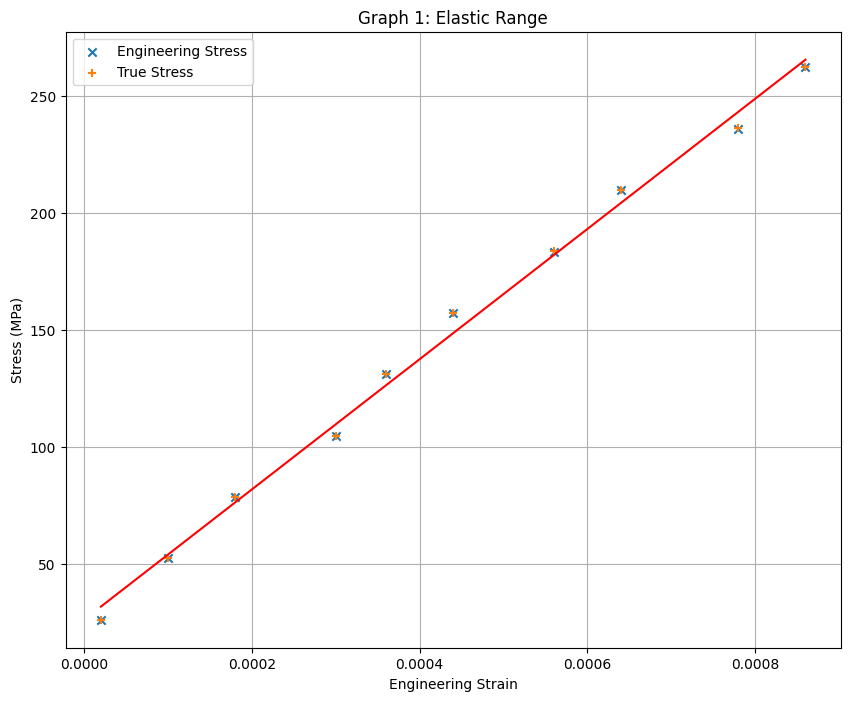

In [21]:
from matplotlib import colors

# =========================================================
# GRAPH 1
# Elastic Range
# =========================================================

plt.figure(figsize=(10,8))

plt.scatter(
    engineering_strain[:elastic_points],
    engineering_stress[:elastic_points],
    label='Engineering Stress',
    marker='x'
)

plt.scatter(
    engineering_strain[:elastic_points],
    true_stress[:elastic_points],
    label='True Stress',
    marker='+'
)

plt.plot(
    engineering_strain[:elastic_points],
    engineering_strain[:elastic_points]*E + intercept,
    color='red'
)

plt.xlabel('Engineering Strain')
plt.ylabel('Stress (MPa)')
plt.title('Graph 1: Elastic Range')
plt.legend()
plt.grid(True)

plt.show()



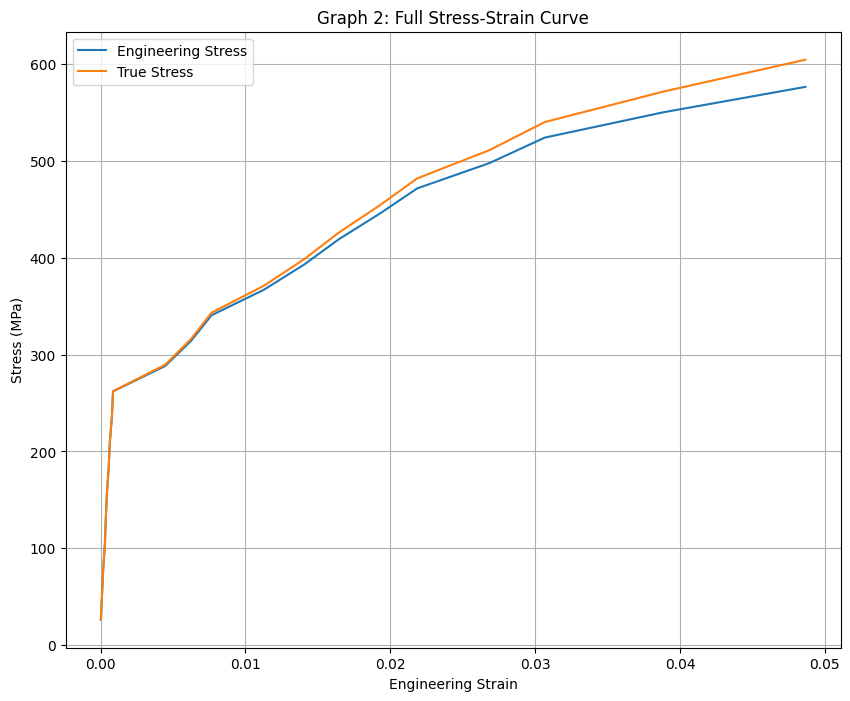

In [22]:

# =========================================================
# GRAPH 2
# Elastic + Inelastic Range
# =========================================================

plt.figure(figsize=(10,8))

plt.plot(
    engineering_strain,
    engineering_stress,
    label='Engineering Stress'
)

plt.plot(
    engineering_strain,
    true_stress,
    label='True Stress'
)

plt.xlabel('Engineering Strain')
plt.ylabel('Stress (MPa)')
plt.title('Graph 2: Full Stress-Strain Curve')
plt.legend()
plt.grid(True)

plt.show()




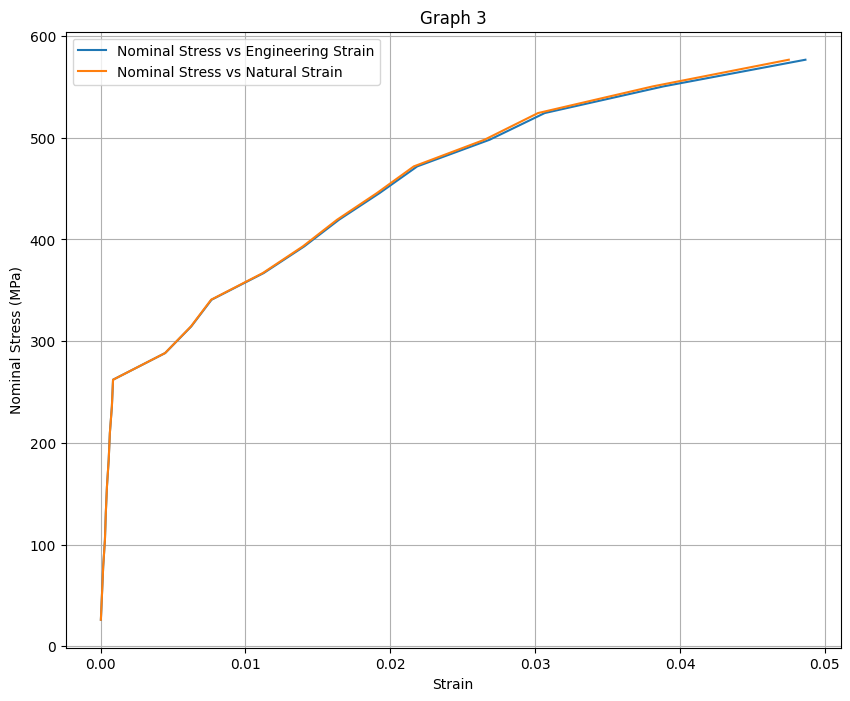

In [23]:
# =========================================================
# GRAPH 3
# Nominal stress vs natural strain
# Nominal stress vs engineering strain
# =========================================================

plt.figure(figsize=(10,8))

plt.plot(
    engineering_strain,
    engineering_stress,
    label='Nominal Stress vs Engineering Strain'
)

plt.plot(
    true_strain,
    engineering_stress,
    label='Nominal Stress vs Natural Strain'
)

plt.xlabel('Strain')
plt.ylabel('Nominal Stress (MPa)')
plt.title('Graph 3')
plt.legend()
plt.grid(True)

plt.show()


## Discussions
1. **Effect of gauge length on percentage elongation**

Percentage elongation is:

$$\% \text{ elongation} = \frac{L_f - L_0}{L_0}\times 100$$

If a larger gauge length is used, the necked region forms a smaller fraction of the total length, so the measured percentage elongation decreases.

If a smaller gauge length is used, the necked region contributes more strongly, so the percentage elongation increases.

Thus, percentage elongation is not purely a material property; it also depends on specimen geometry.

### Engineering implication

Standard testing organizations such as ASTM International and International Organization for Standardization specify standard gauge lengths so results from different tests remain comparable and reliable.

---

2. **Comment on the fracture type**

The specimen showed a ductile fracture.

Characteristics of ductile fracture include:

* large plastic deformation before failure,
* necking,
* high energy absorption,
* gradual failure.

The material elongated significantly before rupture, indicating good ductility. Ductile failure is preferred in engineering structures because it gives warning before complete failure, unlike brittle fracture.

---

3. **Probable error in Young’s modulus**

The main source of error is extension measurement.

Young’s modulus is:

$$E = \frac{\sigma}{\varepsilon}$$

Since elastic extensions are very small, small measurement errors can produce large errors in strain and therefore in (E).

Other possible errors include:

* machine deformation,
* specimen misalignment,
* incorrect selection of the elastic region,
* and errors in diameter or gauge-length measurement.


